In [ ]:
!pip install -U storywrangler

In [ ]:
# latest py-allotax version still on a branch
!pip install git+https://github.com/compstorylab/py-allotax.git@allotax-core

In [4]:
# colab's slim Ubuntu image lacks Chrome's system libraries for writing the allotax plot
# !apt-get -qq update && apt-get -qq install -y libatk1.0-0 libatk-bridge2.0-0 libcups2 libasound2 libgbm1 libnss3 libxkbcommon0 libxcomposite1 libxdamage1 libxfixes3 libxrandr2

In [ ]:
# local packages
from storywrangler import Storywrangler
from py_allotax import allotaxonograph

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

In [6]:
import storywrangler
print(storywrangler.__version__)

0.0.10


In [7]:
client=Storywrangler()

In [8]:
bb = client.dataset("babynames", "ngrams")

Whenever working with instruments, it is worth knowing about [Storywrangler's open specifications](https://storywrangler.uvm.edu/specification) to boost the performance and interoperability of datasets. There are three key conventions:

- `data_schema.type`: setting this to types-counts means the dataset is compatible with the allotaxonometer instrument.
- `time-based` transforms: by declaring time, we know we can take time ranges or aggregate over the dataset.
- `entity-based`: an entity is a distinguishable person, place, organization, concept, event, or work referenced in a corpus (see [here](https://storywrangler.uvm.edu/specification#31-entity-identifier-systems) for more details).

They are optional but offer some guarantees and improve metadata completeness when specified.

In [40]:
# here "year" has been declared as time-dimension
# while "sex" is a filter.
bb.meta['transform']

{'time_dimension': 'year',
 'filter_dimensions': ['sex'],
 'time_partitions': None,
 'hash_bucket': None,
 'hash_algorithm': 'murmur3_32',
 'hash_seed': 0}

In [48]:
# Since we know "year" is a time columns,
# we introspect time range upon registration.
bb.availability

{'quebec': {'min': '1980', 'max': '2024', 'types': 1700},
 'united_states': {'min': '1880', 'max': '2024', 'types': 29225}}

In [39]:
print(bb.meta["entity_mapping"])
print(bb.adapter)

{'local_id_column': 'geo', 'entity_namespace': 'wikidata'}
[{'local_id': 'united_states', 'entity_id': 'wikidata:Q30', 'entity_name': 'United States', 'entity_ids': ['iso:US', 'local:babynames:united_states']}, {'local_id': 'quebec', 'entity_id': 'wikidata:Q176', 'entity_name': 'Quebec', 'entity_ids': ['iso:CA-QC', 'local:babynames:quebec']}]


Here we can use either `local_id` or `entity_id` as entity in the `top_ngrams` query. Whenever using the standardized time-based system, 

In [ ]:
ngram_data= bb.top_ngrams(
    entity="united_states",
    dates=1968, dates2=2018,
    sex="F", 
    limit=bb.availability["united_states"]['types']
)

In [51]:
df1=pd.DataFrame(ngram_data['1968'])
df2=pd.DataFrame(ngram_data['2018'])

In [56]:
# Alpha = Inf
fig = allotaxonograph(df1, df2, "Inf", "Ω1: Baby girl names in 1968", "Ω2: Baby girl names in 2018")

In [57]:
fig.interactive()

This figure is a replication of `Fig. 4` in _Allotaxonometry and rank-turbulence divergence: a universal instrument for comparing complex systems_ (Doods et al. 2023). Pretty cool!

In [ ]:
# saving the chart, requires some JS dependencies
fig.save("chart.pdf") # also supports .svg, .html

First render: installing JS dependencies with npm (downloads Chrome for puppeteer; this can take a few minutes)...
PDF saved to chart.pdf


## Server-side instruments

The platform can run the same computation for you: `/storywrangler/allotax` and `/storywrangler/rtd` work for **every** dataset registered as `types-counts`. Same comparison as above, no download:

In [74]:
from IPython.display import Markdown

Markdown("""
  ```mermaid
graph LR
    A[Rust allotax-core] --> B[py03 binding]
    B --> D[Standalone library]
    B --> C[Storywrangler's API]
    C --> E[Server-side rendered]
  ```
""")


  ```mermaid
graph LR
    A[Rust allotax-core] --> B[py03 binding]
    B --> D[Standalone library]
    B --> C[Storywrangler's API]
    C --> E[Server-side rendered]
  ```


In [75]:
result = bb.allotax(entity="wikidata:Q30", dates=1968, dates2=2018, sex="F", alpha="Inf")
result["wordshift"][:5]

[{'type': 'Lisa (1 ⇋ 1628.5)', 'metric': -0.051610956086315225},
 {'type': 'Liam (11970.5 ⇋ 1)', 'metric': 0.051610956086315225},
 {'type': 'Michelle (2 ⇋ 556)', 'metric': -0.025805478043157613},
 {'type': 'Emma (426.5 ⇋ 2)', 'metric': 0.025805478043157613},
 {'type': 'Noah (11970.5 ⇋ 3)', 'metric': 0.017203652028771742}]

In [76]:
# rtd is the lightweight variant: wordshift only, no diamond — fast enough for interactive use
rtd = bb.rtd(entity="wikidata:Q30", dates=1968, dates2=2018, sex="F")
rtd.df().head(10)

,type,rank1,rank2,divergence
0,Lisa,877.5,1.0,0.000603
1,Emma,1.0,426.5,-0.000582
2,Olivia,2.0,529.0,-0.000492
3,Michelle,263.0,2.0,0.000467
4,Ava,3.0,744.0,-0.000452
5,Isabella,4.0,2668.0,-0.000451
6,Kimberly,173.0,3.0,0.000397
7,Harper,9.0,11860.5,-0.000395
8,Jennifer,344.0,4.0,0.000391
9,Tammy,4037.0,8.0,0.000387


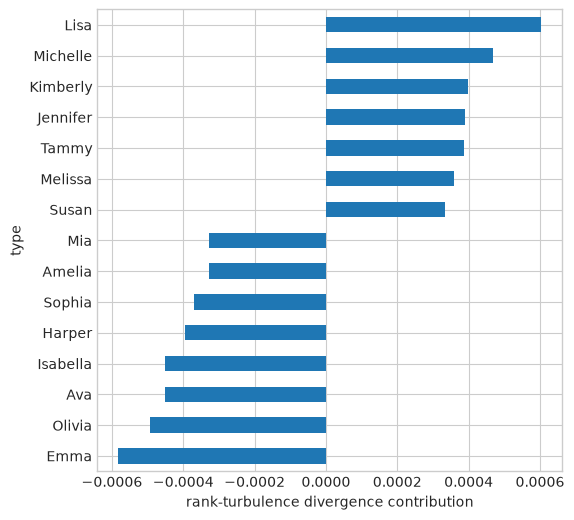

In [ ]:
# which names moved most between 1968 and 2018?
ws = rtd.df().head(15).set_index("type")
ws["divergence"].sort_values().plot.barh(figsize=(6, 6))
plt.xlabel("rank-turbulence divergence contribution");

### The alpha parameter

`alphas=` computes several alphas in one request. Low alpha weighs rank *churn* across the
whole distribution; alpha=inf only sees types that displace the very top.

In [82]:
multi = bb.rtd(entity="wikidata:Q30", dates=1968, dates2=2018, sex="F",
               alphas="0, 0.25,1,inf", wordshift_limit=5)
[(a["alpha"], a["wordshift"][0]["type"]) for a in multi["alpha_results"]]

[(0.0, 'Harper'), (0.25, 'Lisa'), (1.0, 'Lisa'), ('Infinity', 'Emma')]

## Instruments are engine-agnostic

The classic Twitter corpus is served straight from MongoDB — the instrument neither knows nor cares.
Same method, same response shape:

In [83]:
tw = client.dataset("twitter")
tw.rtd(dates="2020-03-15", dates2="2020-02-15", lang="en", wordshift_limit=5).df()

,type,rank1,rank2,divergence
0,coronavirus,1469.0,79.0,0.000162
1,pandemic,11468.5,188.0,0.000162
2,virus,2282.0,99.0,0.000161
3,COVID-19,11468.5,202.0,0.000158
4,➫,205.0,11468.5,-0.000157


In [84]:
# datasets can register several count measures — ?weight= picks one.
# with retweets the top mover is a K-pop hashtag (RT armies); without them, the pandemic:
tw.rtd(dates="2020-03-15", dates2="2020-02-15", lang="en",
       weight="count_noRT", wordshift_limit=5).df()

,type,rank1,rank2,divergence
0,#NCT127,10750.5,360.0,0.000129
1,virus,2077.0,165.0,0.000129
2,#NCT127_KickIt,9779.0,361.0,0.000127
3,#엔시티,10750.5,396.0,0.000125
4,pandemic,10750.5,478.0,0.000117


## Reproducibility ideals (WIP)

In a perfect world, each analysis run through our instruments and data could be reproduced.  That is, you ran allotax on a registered dataset for a paper you submitted in 2025; on the submitter side, this can be cited. On Storywrangler, we provide the means to version the instruments. 

But to reproduce exactly is a little bit challenging as someone needs to maintain a copy of the data exactly as it was when queried. 

## Every result carries its provenance

An instrument result is a function of the **instrument version**, the **data version**, and the
**parameters** — change any of the three and the numbers can change. So every response records
all three in `meta`: `allotax_version` pins the library (immutable on PyPI), `dataset_version`
names the registry slot, and the parameters (plus `types_target`/`types_ref`, the number of
types actually loaded) make the record complete. Rerun later and compare: if the types counts
moved, the data changed under you.

In [ ]:
rtd["meta"]

Datasets can also cut **immutable snapshots** (`version="1.0.0"`): the mutable `latest` slot
keeps moving with the pipeline, while a snapshot freezes the registration — and, for datasets
like babynames whose file list is copy-on-write, the exact bytes — forever. That is what makes
`dataset_version` citable in a paper.

In [ ]:
[(v["version"], v["created_at"][:10]) for v in bb.versions()["versions"]]